In [52]:
import os
import gymnasium as gym
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

import imageio
from IPython.display import Image, display
from google.colab import drive

print("PyTorch version: " + torch.__version__)

# Podesavanje uređaja (GPU ako je dostupan, inače CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uređaj: {device}")

PyTorch version: 2.11.0+cu128
Koristi se uređaj: cuda


In [53]:
########################################################################################################################
# MONTIRANJE GOOGLE DRIVE-A
########################################################################################################################

drive.mount('/content/drive')

drive_results_folder = '/content/drive/MyDrive/CartPoleDQN_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

# Definisanje putanja
agent_path = os.path.join(drive_results_folder, "CartPoleDQN_agent.pth")
fig_path = os.path.join(drive_results_folder, "CartPoleDQN_training.png")
gif_path = os.path.join(drive_results_folder, "CartPoleDQN_demo.gif")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
########################################################################################################################
# DQN AGENT KLASA
########################################################################################################################

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        # Experience Replay bafer (pamti poslednjih 10000 koraka)
        self.memory = deque(maxlen=10000)

        # Hiperparametri
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.99
        self.learning_rate = 0.0003
        self.tau = 0.005

        # Inicijalizacija modela, optimizatora i funkcije gubitka
        self.model = self._build_model().to(device)

        # Ciljna mreža za stabilizaciju učenja
        self.target_model = self._build_model().to(device)
        self.target_model.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        # HUBER LOSS sprečava destrukciju težina pri velikim greškama
        self.criterion = nn.SmoothL1Loss()

    def _build_model(self):
        model = nn.Sequential(
            nn.Linear(self.state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, self.action_size)
        )
        return model

    def update_target_network(self):
        # Prebacujemo samo 0.5% (tau) novog znanja u svakom koraku (soft update)
        for target_param, local_param in zip(self.target_model.parameters(), self.model.parameters()):
            target_param.data.copy_(self.tau * local_param.data + (1.0 - self.tau) * target_param.data)

    def remember(self, state, action, reward, next_state, done):
        # Čuvanje tranzicije u replay memoriju
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        # Prebacivanje NumPy niza u PyTorch tenzor
        state_tensor = torch.FloatTensor(state).to(device)

        # Deaktivacija računanja gradijenata (brže izvršavanje pri inferenciji)
        with torch.no_grad():
            act_values = self.model(state_tensor)

        return torch.argmax(act_values).item()

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)

        # Pretvaranje listi u PyTorch tenzore i prebacivanje na CPU/GPU
        states = torch.FloatTensor(np.vstack([t[0] for t in minibatch])).to(device)
        actions = torch.LongTensor([t[1] for t in minibatch]).unsqueeze(1).to(device)
        rewards = torch.FloatTensor([t[2] for t in minibatch]).to(device)
        next_states = torch.FloatTensor(np.vstack([t[3] for t in minibatch])).to(device)
        dones = torch.FloatTensor([t[4] for t in minibatch]).to(device)

        # Dobijanje Q-vrednosti za izabrane akcije
        # .gather(1, actions) izvlači samo one izlaze iz mreže koji odgovaraju preduzetoj akciji
        q_values = self.model(states).gather(1, actions).squeeze(1)

        # Dobijanje maksimalnih Q-vrednosti za sledeća stanja
        with torch.no_grad():
            next_q_values = self.target_model(next_states).max(1)[0]

        # Računanje ciljnih (target) vrednosti (Bellmanova jednačina)
        targets = rewards + (1 - dones) * self.gamma * next_q_values

        # Računanje gubitka (Loss)
        loss = self.criterion(q_values, targets)

        # Optimizacioni korak (Poništavanje starih gradijenata, backprop, primena učenja)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

Započinjem obučavanje...
Epizoda: 1/500 | Rezultat: 19 | Epsilon: 1.00
Epizoda: 2/500 | Rezultat: 14 | Epsilon: 0.99
Epizoda: 3/500 | Rezultat: 23 | Epsilon: 0.98
Epizoda: 4/500 | Rezultat: 27 | Epsilon: 0.97
Epizoda: 5/500 | Rezultat: 16 | Epsilon: 0.96
Epizoda: 6/500 | Rezultat: 13 | Epsilon: 0.95
Epizoda: 7/500 | Rezultat: 22 | Epsilon: 0.94
Epizoda: 8/500 | Rezultat: 69 | Epsilon: 0.93
Epizoda: 9/500 | Rezultat: 9 | Epsilon: 0.92
Epizoda: 10/500 | Rezultat: 22 | Epsilon: 0.91
Epizoda: 11/500 | Rezultat: 10 | Epsilon: 0.90
Epizoda: 12/500 | Rezultat: 16 | Epsilon: 0.90
Epizoda: 13/500 | Rezultat: 14 | Epsilon: 0.89
Epizoda: 14/500 | Rezultat: 13 | Epsilon: 0.88
Epizoda: 15/500 | Rezultat: 11 | Epsilon: 0.87
Epizoda: 16/500 | Rezultat: 34 | Epsilon: 0.86
Epizoda: 17/500 | Rezultat: 40 | Epsilon: 0.85
Epizoda: 18/500 | Rezultat: 28 | Epsilon: 0.84
Epizoda: 19/500 | Rezultat: 33 | Epsilon: 0.83
Epizoda: 20/500 | Rezultat: 43 | Epsilon: 0.83
Epizoda: 21/500 | Rezultat: 17 | Epsilon: 0.8

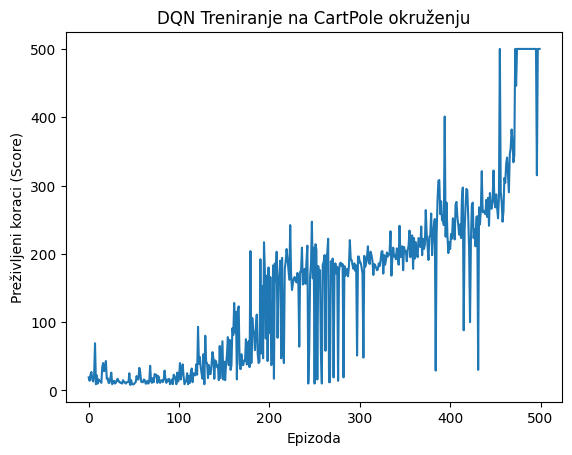

In [55]:
########################################################################################################################
# GLAVNA PETLJA ZA OBUČAVANJE
########################################################################################################################

env = gym.make('CartPole-v1')
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

agent = DQNAgent(state_size, action_size)
episodes = 500
batch_size = 128

scores = []

print("Započinjem obučavanje...")
for e in range(episodes):
    state, info = env.reset()
    state = np.reshape(state, [1, state_size])

    time_steps = 0
    done = False

    while not done:
        action = agent.act(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Kažnjavamo agenta samo ako je klatno palo (terminated).
        if terminated:
            reward = -10

        next_state = np.reshape(next_state, [1, state_size])

        agent.remember(state, action, reward, next_state, terminated)

        state = next_state
        time_steps += 1

        agent.replay(batch_size)

        if done:
            print(f"Epizoda: {e+1}/{episodes} | Rezultat: {time_steps} | Epsilon: {agent.epsilon:.2f}")
            scores.append(time_steps)
            break

    # Ažuriranje ciljne mreže (jednom po epizodi)
    agent.update_target_network()

    # Smanjenje epsilona (jednom po epizodi)
    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay

# Snimanje modela (U PyTorch-u je standard snimati samo "state_dict" odnosno težine)
torch.save(agent.model.state_dict(), agent_path)
print(f"Težine modela su uspešno sačuvane u fajl '{agent_path}'!")

plt.plot(scores)
plt.ylabel('Preživljeni koraci (Score)')
plt.xlabel('Epizoda')
plt.title('DQN Treniranje na CartPole okruženju')
plt.savefig(fig_path)
plt.show()

Obučeni model je uspešno učitan sa diska.
Pokrećem obučenog agenta i snimam frejmove...
Epizoda završena nakon 500 koraka. Generišem GIF animaciju...


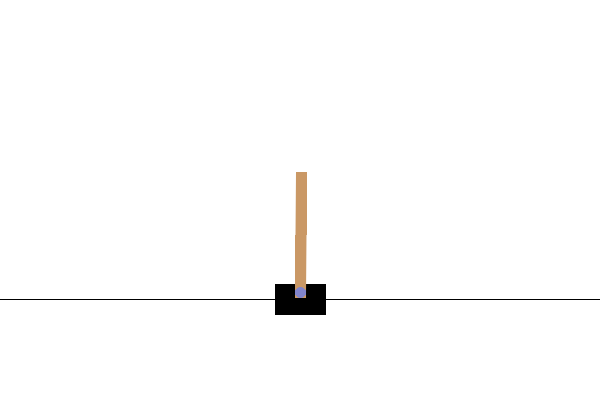

In [56]:
########################################################################################################################
# VIZUELIZACIJA RADA OBUČENOG AGENTA
########################################################################################################################

# Re-kreiranje agenta mreže za inferenciju
loaded_agent = DQNAgent(state_size, action_size)

# Učitavanje sačuvanih težina u model unutar našeg agenta
loaded_agent.model.load_state_dict(torch.load(agent_path, weights_only=True))
loaded_agent.model.eval() # Prebacivanje u evaluacioni mod

# Gasimo stopu istraživanja jer sada isključivo eksploatišemo naučeno
loaded_agent.epsilon = 0.0

print("Obučeni model je uspešno učitan sa diska.")

# Inicijalizacija okruženja
env_render = gym.make('CartPole-v1', render_mode='rgb_array')

state, info = env_render.reset()
state = np.reshape(state, [1, state_size])

frames = []
done = False
time_steps = 0

print("Pokrećem obučenog agenta i snimam frejmove...")

while not done:
    # Preuzimamo trenutni izgled ekrana i dodajemo ga u listu frejmova
    frames.append(env_render.render())

    # Elegantno koristimo act() metodu klase pošto je epsilon 0.0, agent će uvek birati najbolju akciju.
    action = loaded_agent.act(state)

    next_state, reward, terminated, truncated, info = env_render.step(action)
    done = terminated or truncated

    state = np.reshape(next_state, [1, state_size])
    time_steps += 1

env_render.close()

print(f"Epizoda završena nakon {time_steps} koraka. Generišem GIF animaciju...")

# imageio nova sintaksa: duration = milisekunde po frejmu (1000ms / 30fps)
# loop=0 znači da će se GIF vrteti u krug beskonačno
imageio.mimsave(gif_path, frames, duration=1000/30, loop=0)

# Prikazivanje GIF-a
display(Image(filename=gif_path))